# Actividad Individual Data Wrangling - PARTE A

**Angel Irwin Briseño Fierro A01796844**

En esta practica se realizara el EDA y proceso de limpieza de los datasets provistos "room-occupancy-estimation", original y modificado, con la finalidad de obtener una comparacion tal que evidencie la influencia de estos procesos en los datos y que pueden repercutir en procesos mas adelante en el desarrollo de modelos de ML.

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as  plt
import seaborn as sns
import json
from pathlib import Path

## Cargar Dataset original

In [61]:
ogDf = pd.read_csv(r'D:\Master\MLops\A03_Data_Cleaning_EDA\room-occupancy-estimation\original.csv', keep_default_na=False)
# ogDf = pd.read_csv('./original.csv', keep_default_na=False)
ogDf.head()

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,2017/12/22,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1
2,2017/12/22,10:50:42,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1
3,2017/12/22,10:51:13,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1
4,2017/12/22,10:51:44,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1


In [62]:
ogDf.describe().T

,count,mean,std,min,25%,50%,75%,max
S1_Temp,10129.0,25.454012,0.351351,24.940000,25.190000,25.38,25.63,26.380000
S2_Temp,10129.0,25.546059,0.586325,24.750000,25.190000,25.38,25.63,29.000000
S3_Temp,10129.0,25.056621,0.427283,24.440000,24.690000,24.94,25.38,26.190000
S4_Temp,10129.0,25.754125,0.356434,24.940000,25.440000,25.75,26.00,26.560000
S1_Light,10129.0,25.445059,51.011264,0.000000,0.000000,0.00,12.00,165.000000
S2_Light,10129.0,26.016290,67.304170,0.000000,0.000000,0.00,14.00,258.000000
S3_Light,10129.0,34.248494,58.400744,0.000000,0.000000,0.00,50.00,280.000000
S4_Light,10129.0,13.220259,19.602219,0.000000,0.000000,0.00,22.00,74.000000
S1_Sound,10129.0,0.168178,0.316709,0.060000,0.070000,0.08,0.08,3.880000
S2_Sound,10129.0,0.120066,0.266503,0.040000,0.050000,0.05,0.06,3.440000


In [63]:
print(f"Rows: {ogDf.shape[0]:,}")
print(f"Columns: {ogDf.shape[1]}")

# Compact data-quality summary
data_quality = pd.DataFrame({
    "dtype": ogDf.dtypes,
    "missing": ogDf.isna().sum(),
    "missing_pct": ogDf.isna().mean() * 100,
    "n_unique": ogDf.nunique()
})

data_quality.sort_values("missing_pct", ascending=False)

Rows: 10,129
Columns: 19


,dtype,missing,missing_pct,n_unique
Date,object,0,0.0,7
Time,object,0,0.0,10129
S1_Temp,float64,0,0.0,24
S2_Temp,float64,0,0.0,69
S3_Temp,float64,0,0.0,29
S4_Temp,float64,0,0.0,27
S1_Light,int64,0,0.0,68
S2_Light,int64,0,0.0,82
S3_Light,int64,0,0.0,177
S4_Light,int64,0,0.0,75


In [64]:
n_duplicates = ogDf.duplicated().sum()
duplicate_pct = 100 * n_duplicates / len(ogDf)

print(f"Duplicated rows: {n_duplicates:,}")
print(f"Percentage of duplicated rows: {duplicate_pct:.2f}%")

Duplicated rows: 0
Percentage of duplicated rows: 0.00%


In [65]:
exclude = ["Date", "Time"]

for col in ogDf.columns:
    if col not in exclude:
        ogDf[col] = pd.to_numeric(ogDf[col], errors="coerce")
        
numeric_features = [
    col for col in ogDf.select_dtypes(include=np.number).columns
    if col != "Room_Occupancy_Count"
]

univariate_summary = ogDf[numeric_features].describe().T

univariate_summary["median"] = ogDf[numeric_features].median()
univariate_summary["skewness"] = ogDf[numeric_features].skew()
univariate_summary["kurtosis"] = ogDf[numeric_features].kurt()

univariate_summary[
    ["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max",
     "skewness", "kurtosis"]
].sort_values("skewness", key=lambda x: x.abs(), ascending=False)

,count,mean,median,std,min,25%,50%,75%,max,skewness,kurtosis
S4_Sound,10129.0,0.103840,0.08,0.120683,0.050000,0.060000,0.08,0.10,3.400000,10.952134,211.172069
S2_Sound,10129.0,0.120066,0.05,0.266503,0.040000,0.050000,0.05,0.06,3.440000,6.881610,62.472799
S3_Sound,10129.0,0.158119,0.06,0.413637,0.040000,0.060000,0.06,0.07,3.670000,5.994767,39.477822
S1_Sound,10129.0,0.168178,0.08,0.316709,0.060000,0.070000,0.08,0.08,3.880000,5.450448,39.415196
S7_PIR,10129.0,0.079574,0.00,0.270645,0.000000,0.000000,0.00,0.00,1.000000,3.107460,7.657822
S6_PIR,10129.0,0.090137,0.00,0.286392,0.000000,0.000000,0.00,0.00,1.000000,2.862811,6.196913
S2_Light,10129.0,26.016290,0.00,67.304170,0.000000,0.000000,0.00,14.00,258.000000,2.827817,6.187379
S2_Temp,10129.0,25.546059,25.38,0.586325,24.750000,25.190000,25.38,25.63,29.000000,2.355681,6.506295
S3_Light,10129.0,34.248494,0.00,58.400744,0.000000,0.000000,0.00,50.00,280.000000,2.100069,3.885540
S5_CO2,10129.0,460.860401,360.00,199.964940,345.000000,355.000000,360.00,465.00,1270.000000,1.975692,3.001375


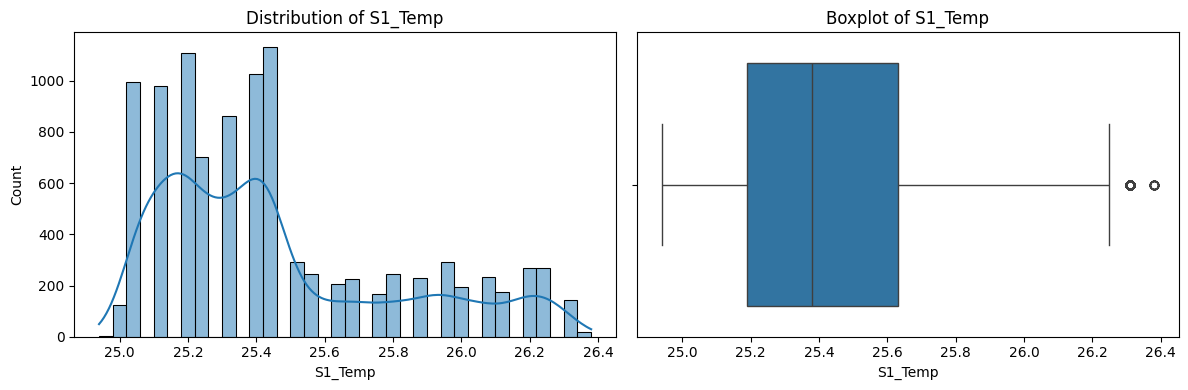

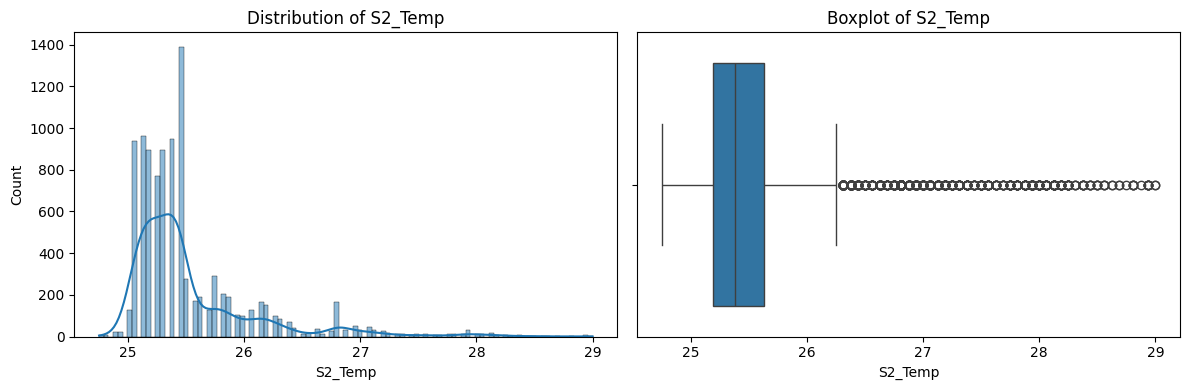

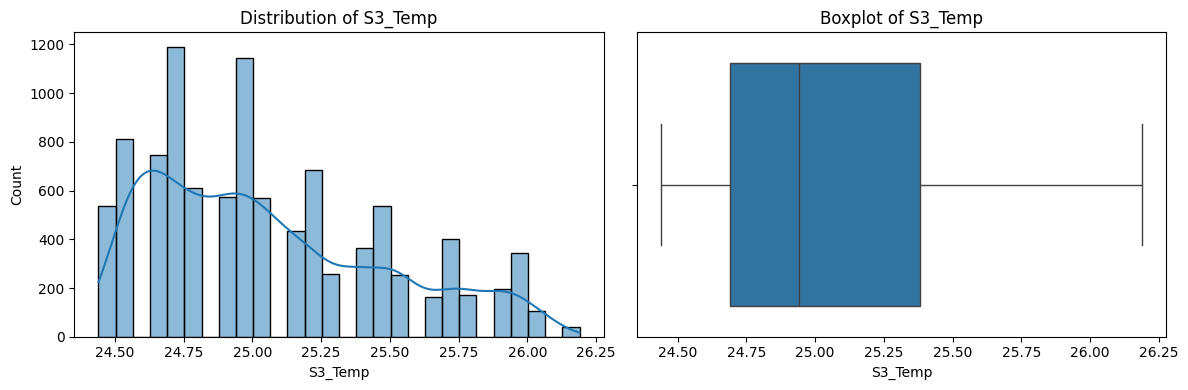

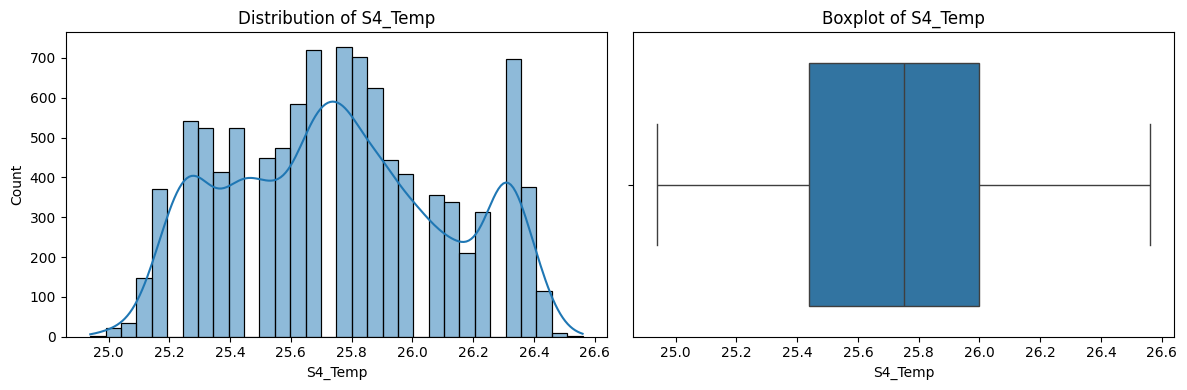

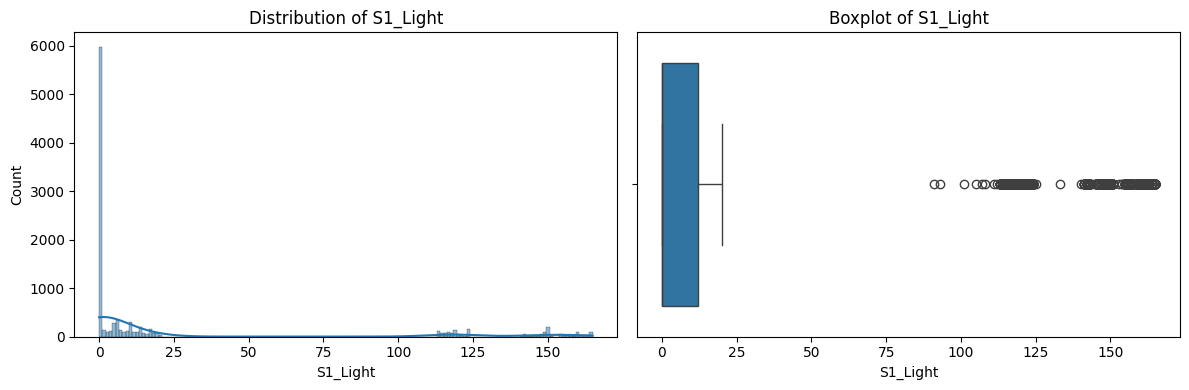

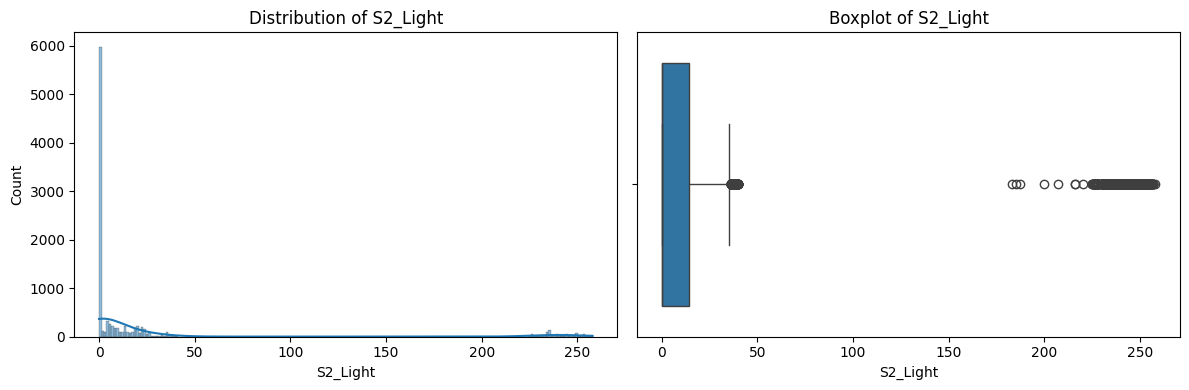

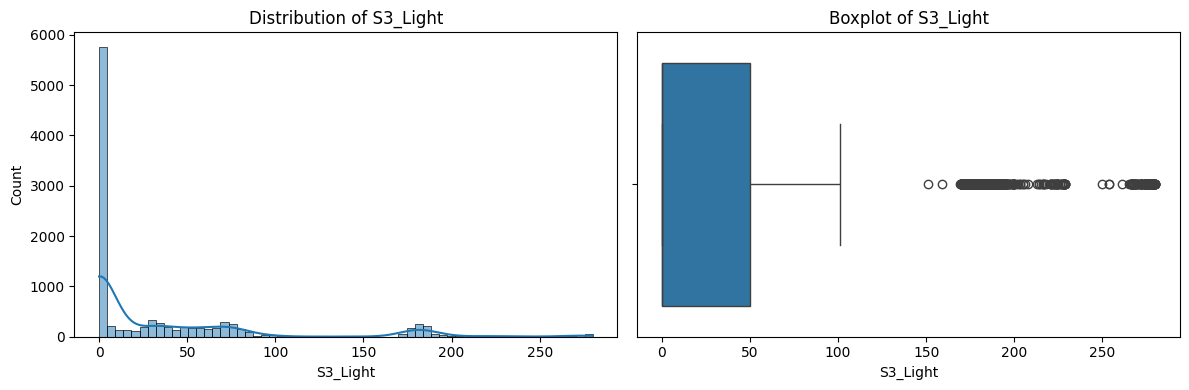

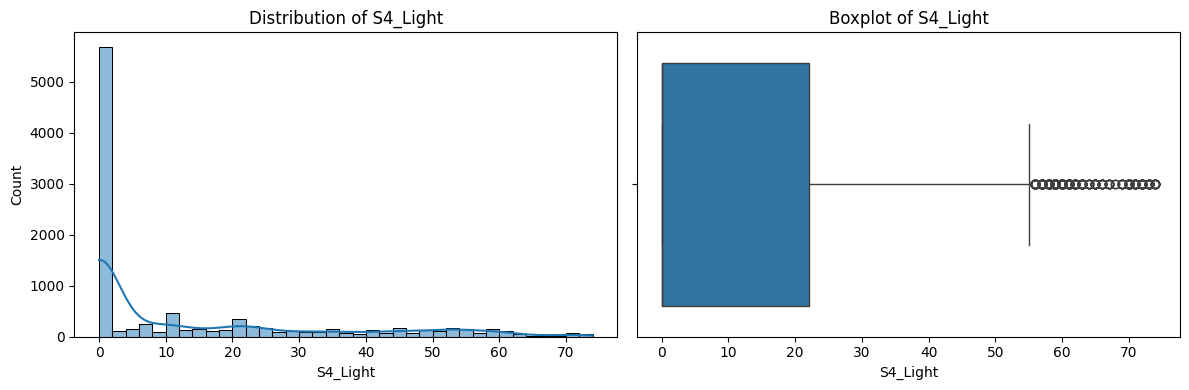

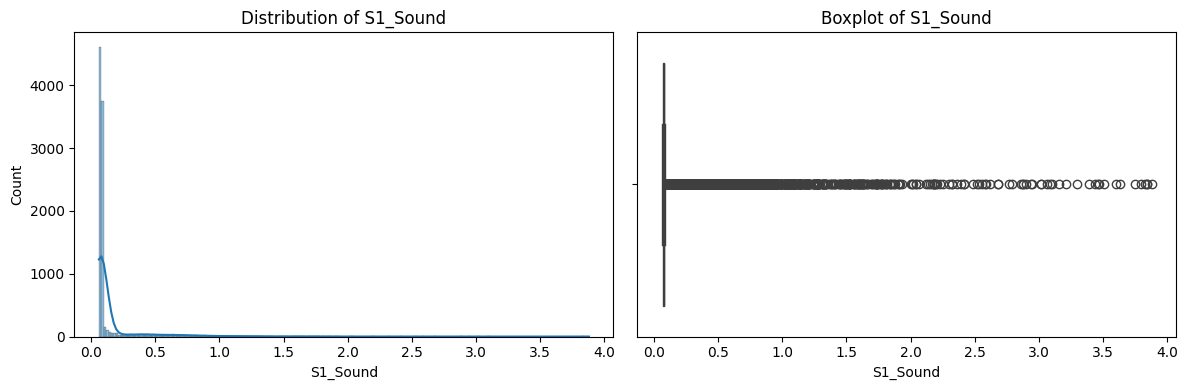

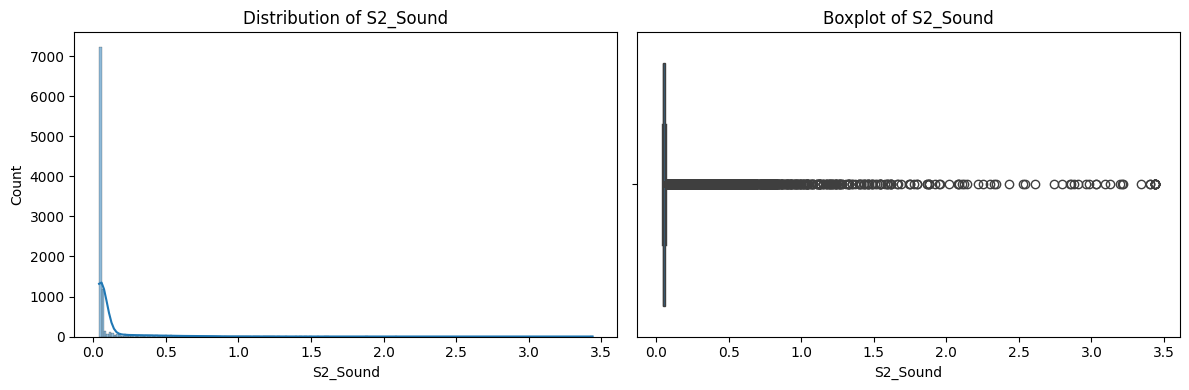

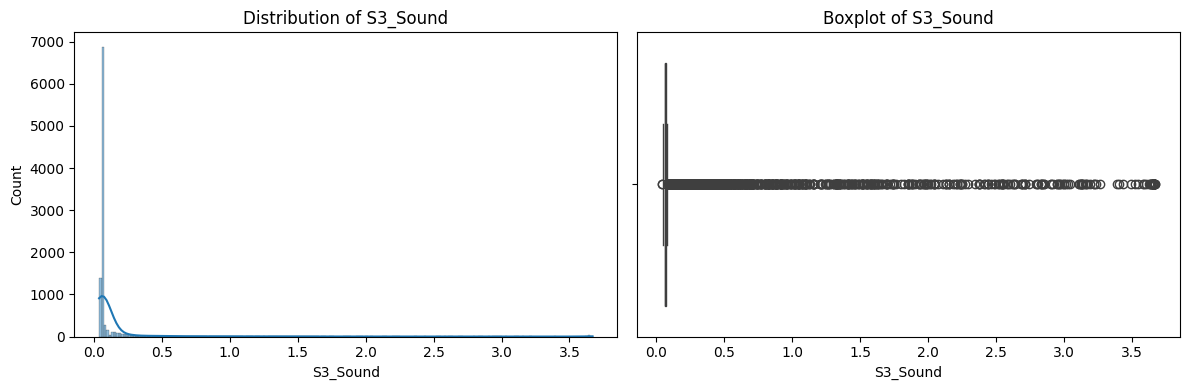

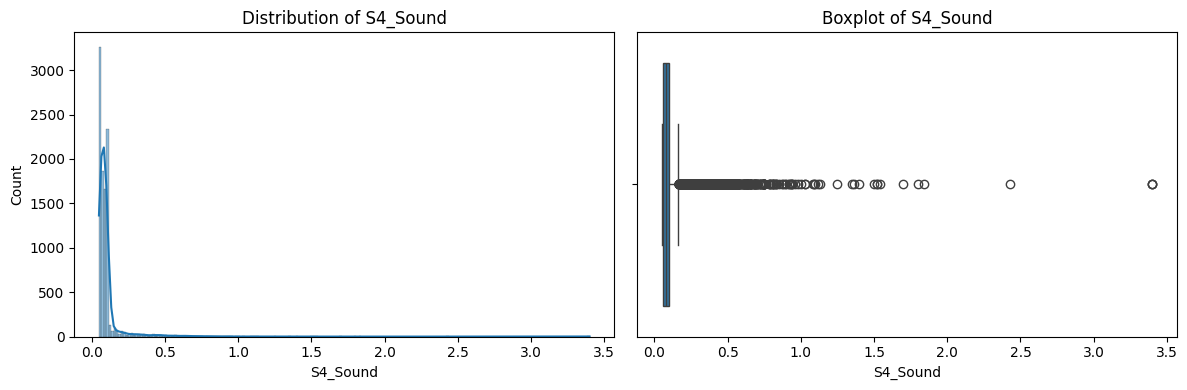

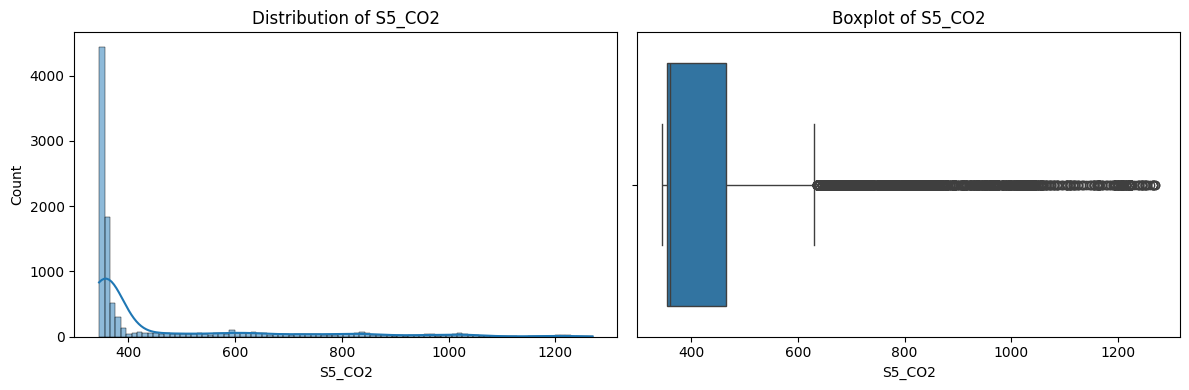

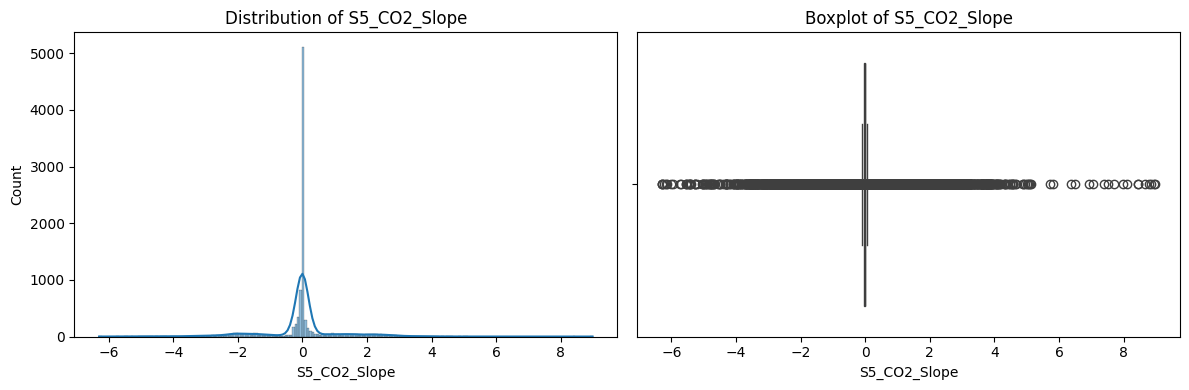

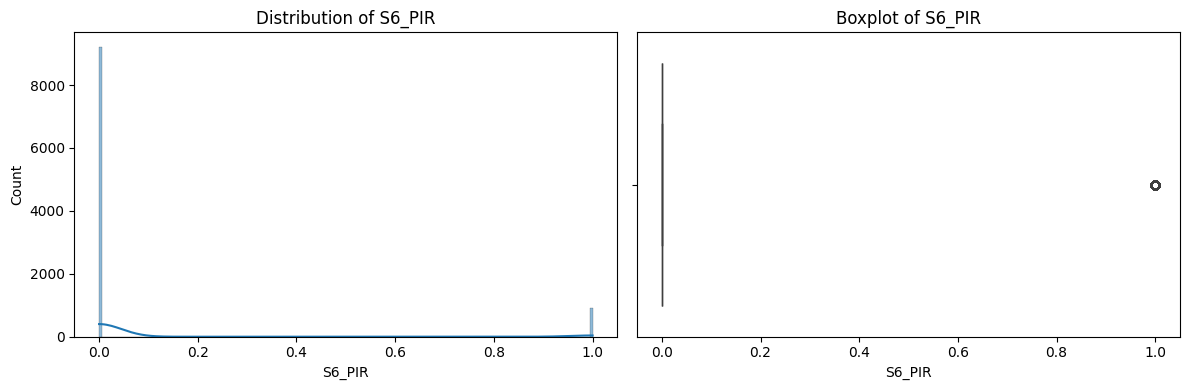

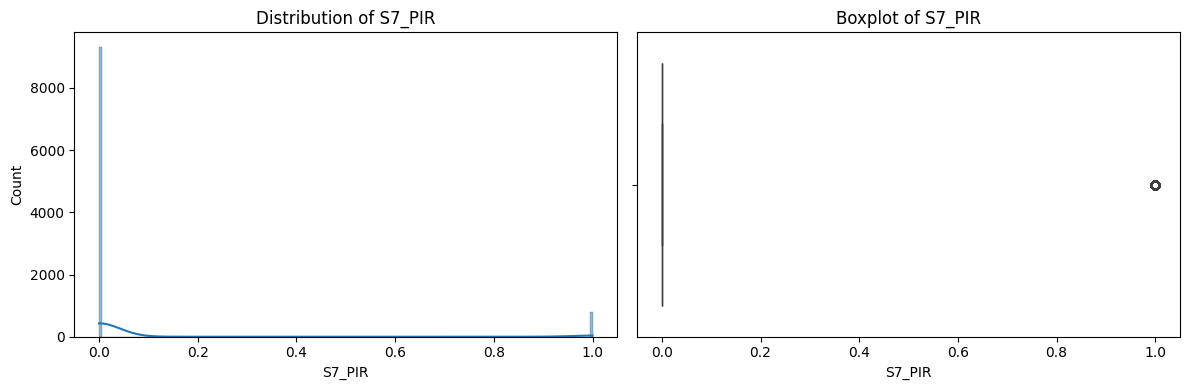

In [66]:
# Distribution + boxplot for every numerical predictor
for column in numeric_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(
        data=ogDf,
        x=column,
        kde=True,
        ax=axes[0]
    )
    axes[0].set_title(f"Distribution of {column}")

    sns.boxplot(
        data=ogDf,
        x=column,
        ax=axes[1]
    )
    axes[1].set_title(f"Boxplot of {column}")

    plt.tight_layout()
    plt.show()

**Análisis de la variable objetivo**

Con base en los datos presentados, la variable room_ocupancy_count puede ser utilizada como variable objetivo.
Al verificar las clases, se puede observar un gran desbalance en las variables, la clase 0 (sin ser ocupados) ocupa mas del 80% mas de los registros. 

In [67]:
quality_summary = pd.DataFrame({
    "count": ogDf["Room_Occupancy_Count"].value_counts().sort_index(),
    "percentage": ogDf["Room_Occupancy_Count"].value_counts(normalize=True).sort_index() * 100
})

quality_summary

,count,percentage
Room_Occupancy_Count,,
0,8228,81.232106
1,459,4.531543
2,748,7.384737
3,694,6.851614


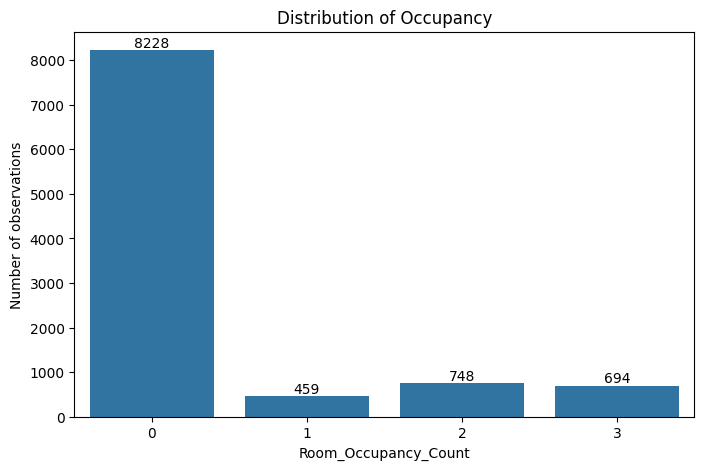

In [68]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=ogDf, x="Room_Occupancy_Count")

plt.title("Distribution of Occupancy")
plt.xlabel("Room_Occupancy_Count")
plt.ylabel("Number of observations")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

# Dataset modificado

In [69]:
metadata = json.loads(Path(r'D:\Master\MLops\A03_Data_Cleaning_EDA\room-occupancy-estimation\metadata.json').read_text())
# metadata = json.loads(Path('./metadata.json').read_text())
print(metadata['rates'])

{'dup_rate': 0.02, 'nan_rate': 0.01, 'outlier_rate': 0.01, 'bad_token_rate': 0.005, 'obj_noise_rate': 0.05, 'add_mixed_type': True}


In [70]:
modDf = pd.read_csv(r'D:\Master\MLops\A03_Data_Cleaning_EDA\room-occupancy-estimation\modified.csv')
# ogDf = pd.read_csv('./modified.csv')
modDf.head()

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count,mixed_type_col
0,2017/12/22,10:49:41,24.94,345.75,24.56,25.38,121.0,34.0,53.0,40.0,0.08,0.19,0.06,0.06,390.0,0.769230769231,0.0,0.0,1.0,599
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121.0,33.0,53.0,40.0,0.93,0.05,0.06,0.06,390.0,0.646153846154,0.0,0.0,1.0,NaN
2,2017/12/22,10:50:42,25.0,24.75,24.5,25.44,121.0,34.0,53.0,40.0,0.43,0.11,0.08,0.06,390.0,0.519230769231,0.0,0.0,1.0,unknown
3,2017/12/22,10:51:13,25.0,24.75,24.56,25.44,121.0,34.0,53.0,40.0,0.41,0.1,0.1,0.09,390.0,0.388461538462,0.0,0.0,1.0,584
4,2017/12/22,10:51:44,25.0,24.75,24.56,25.44,121.0,34.0,54.0,40.0,0.18,0.06,0.06,0.06,390.0,0.253846153846,0.0,0.0,1.0,bad


Se menciona en la metadata que la columna "Add_mixed_type" fue añadida, por lo que en la tabla original no existe, ademas se observa que, como su nombre lo dice, multiples valores de diferente tipo, por lo que puede ser removida del analisis

In [71]:
modDf.drop(axis=1, labels=['mixed_type_col'],inplace=True)

Para comenzar se verificará el tipo de dato detectado por Pandas, en este caso detecto todo del tipo "object" lo que indica que todos los campos podrian estar contaminados con caracteres o valores incorrectos.

In [88]:
print(f"Rows: {modDf.shape[0]:,}")
print(f"Columns: {modDf.shape[1]}")

# Compact data-quality summary
data_quality = pd.DataFrame({
    "dtype": modDf.dtypes,
    "missing": modDf.isna().sum(),
    "missing_pct": modDf.isna().mean() * 100,
    "n_unique": modDf.nunique()
})

data_quality.sort_values("missing_pct", ascending=False)

Rows: 10,331
Columns: 19


,dtype,missing,missing_pct,n_unique
Room_Occupancy_Count,object,132,1.277708,56
S3_Light,object,131,1.268028,338
S2_Temp,object,128,1.238989,228
S3_Temp,object,124,1.200271,169
S2_Light,object,122,1.180912,218
S5_CO2,object,121,1.171232,381
S4_Light,object,118,1.142193,227
S7_PIR,object,116,1.122834,54
S2_Sound,object,115,1.113155,322
S1_Temp,object,115,1.113155,160


## Pruebas diagnosticas

### Variables numericas

In [73]:
numeric_cols = [
    "S1_Temp", "S2_Temp", "S3_Temp", "S4_Temp",
    "S1_Light", "S2_Light", "S3_Light", "S4_Light",
    "S1_Sound", "S2_Sound", "S3_Sound", "S4_Sound",
    "S5_CO2", "S5_CO2_Slope",
    "Room_Occupancy_Count"
]

def numericErrors(df : pd.DataFrame, colList : list):
    """
    This function is intented to be use with columns in a dataframe that are not register as numeric type but it should be consider as such.
    
        Parameters:

        df : Dataframe to be analize.
    
        colList : List that contain the numeric columns to be analized.

        Returns:

        List :  0 - Error Dataframe(Contains the row number, the column name and the incompatible value), 1 - List with row number that are duplicate 

        
    """
    errors = []
    for col in colList:
        converted = pd.to_numeric(df[col], errors="coerce")
        invalid = df[col].notna() & converted.isna()

        for idx in df.index[invalid]:
            errors.append({
                "row": idx,
                "column": col,
                "value": df.loc[idx, col]
            })
    e_df = pd.DataFrame(errors)
    same_id_rows = e_df[e_df.duplicated(subset=["row"], keep=False)]

    return [e_df,list(set(same_id_rows['row'].to_list()))]

numError_DF, numError_sameRow = numericErrors(modDf,numeric_cols)

print(f'Columnas analizadas: {len(numeric_cols)}')
print(f'Filas con valores erroneos: {numError_DF.shape[0]}')
print(f'Filas con mas de un valor erroneo: {len(numError_sameRow)}')

numError_DF.nunique()


Columnas analizadas: 15
Filas con valores erroneos: 565
Filas con mas de un valor erroneo: 19


row       546
column     15
value       9
dtype: int64

In [74]:
numError_DF.head()

,row,column,value
0,29,S1_Temp,?
1,152,S1_Temp,?
2,154,S1_Temp,?
3,261,S1_Temp,invalid
4,299,S1_Temp,?


Se registraron en total 565 casos con 19 casos que ocurren en la misma fila. Se generarán dos DF para la prueba, uno donde se eliminarán estas columnas, otra donde solo se eliminaran los 19 casos con mas de un valor numerico faltante y se imputará el valor con el metodo que mas adecuado.

In [75]:
bad_rows = numError_DF["row"].unique()
modDF_delR = modDf.drop(index=bad_rows).copy()

modDF_delR[numeric_cols] = modDF_delR[numeric_cols].apply(
pd.to_numeric
)

modDF_delR.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9785 entries, 0 to 10330
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  9699 non-null   object 
 1   Time                  9685 non-null   object 
 2   S1_Temp               9676 non-null   float64
 3   S2_Temp               9663 non-null   float64
 4   S3_Temp               9668 non-null   float64
 5   S4_Temp               9682 non-null   float64
 6   S1_Light              9677 non-null   float64
 7   S2_Light              9670 non-null   float64
 8   S3_Light              9657 non-null   float64
 9   S4_Light              9675 non-null   float64
 10  S1_Sound              9682 non-null   float64
 11  S2_Sound              9671 non-null   float64
 12  S3_Sound              9685 non-null   float64
 13  S4_Sound              9695 non-null   float64
 14  S5_CO2                9669 non-null   float64
 15  S5_CO2_Slope          968

#### Validación de rangos de dominio

* Rango de temperatura "normal" = 10 - 40 C
* Rango "normal" de iluminación = 0 - 300 lux (300 lux es considerado apropiado para areas de conferencia pero aun apropiado)
* Rango normal de CO2 = 0 - 1000 ppm (de acuerdo con [2])
* Rango de personas por habitacion = 0 - 4 (No hay indicación real de cual es el limite por lo que se pondrá a prueba)
* Rango normal de sonido = 0 - 5 v (si el dataset es [3], el voltage tipico de sensores varía podria ser 3.3 o 5v)

Referencias:
1. Lumenloop. (s. f.). Hotel lighting calculator. lumenloop.co.uk
2. CO2 Meter. (2026, 3 de agosto). Carbon Dioxide Levels Chart. CO2Meter.com. https://www.co2meter.com/blogs/news/carbon-dioxide-indoor-levels-chart
3. Ananth, R. (2021). Room Occupancy Estimation Data Set [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/ananthr1/room-occupancy-estimation-data-set/data

In [96]:
rangeTemp = [10.0,40.0]
rangeLux = [0,300.0]
rangoCo2 = [0,1000]
rangoP = [0,4]
rangoSonido = [0,5]
modDf_NumC = modDF_delR.loc[(modDF_delR.S1_Temp.between(*rangeTemp)) & (modDF_delR.S2_Temp.between(*rangeTemp)) & (modDF_delR.S3_Temp.between(*rangeTemp)) & (modDF_delR.S4_Temp.between(*rangeTemp)) & 
                               (modDF_delR.S1_Light.between(*rangeLux)) & (modDF_delR.S2_Light.between(*rangeLux)) & (modDF_delR.S3_Light.between(*rangeLux)) & (modDF_delR.S4_Light.between(*rangeLux)) &
                               (modDF_delR.S5_CO2.between(*rangoCo2)) &
                               (modDF_delR.S1_Sound.between(*rangoSonido)) & (modDF_delR.S2_Sound.between(*rangoSonido)) & (modDF_delR.S3_Sound.between(*rangoSonido)) & (modDF_delR.S4_Sound.between(*rangoSonido)) &
                               (modDF_delR.Room_Occupancy_Count.between(*rangoP))]

modDf_NumC.describe().T

,count,mean,std,min,25%,50%,75%,max
S1_Temp,7246.0,25.418423,0.317437,24.940000,25.190000,25.38,25.56,26.31
S2_Temp,7246.0,25.494019,0.526505,24.750000,25.190000,25.38,25.56,29.00
S3_Temp,7246.0,25.014398,0.393506,24.440000,24.690000,24.94,25.25,26.13
S4_Temp,7246.0,25.723599,0.341785,24.940000,25.440000,25.75,25.94,26.50
S1_Light,7246.0,21.696384,47.897294,0.000000,0.000000,0.00,10.00,299.00
S2_Light,7246.0,21.995446,61.817417,0.000000,0.000000,0.00,10.00,290.00
S3_Light,7246.0,29.069004,52.751005,0.000000,0.000000,0.00,41.00,280.00
S4_Light,7246.0,13.138973,20.386720,0.000000,0.000000,0.00,22.00,236.00
S1_Sound,7246.0,0.157604,0.318322,0.060000,0.070000,0.08,0.08,4.86
S2_Sound,7246.0,0.122000,0.321818,0.040000,0.050000,0.05,0.06,4.75


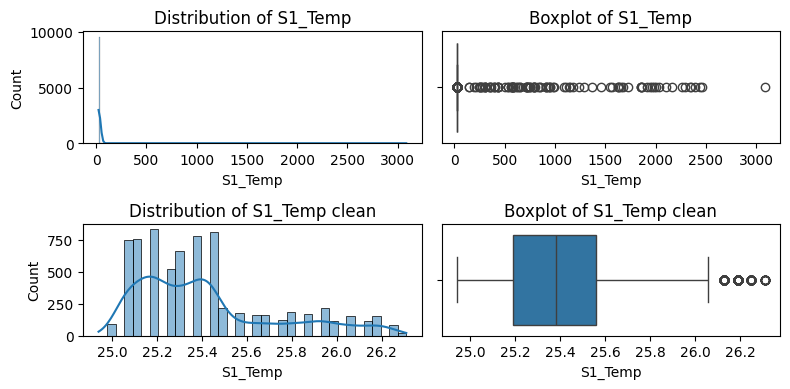

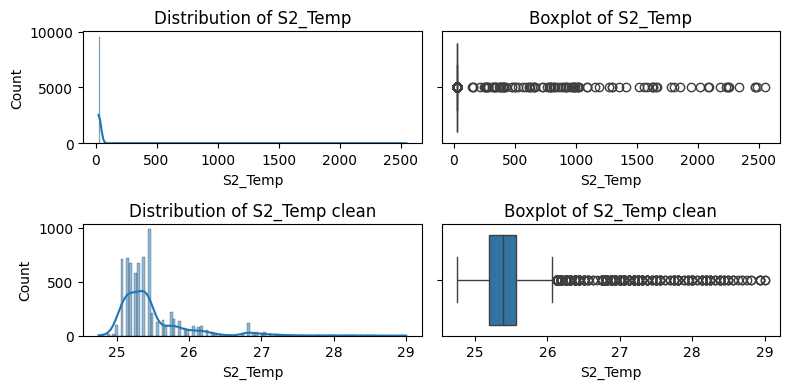

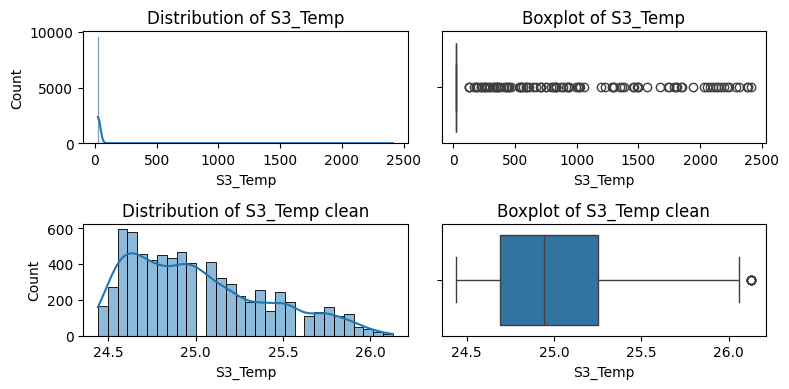

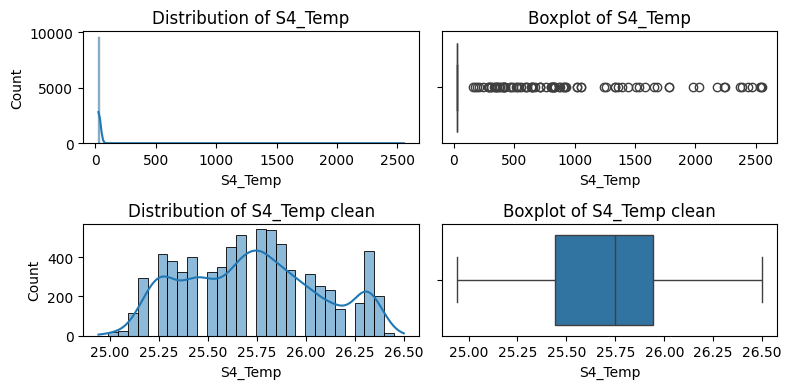

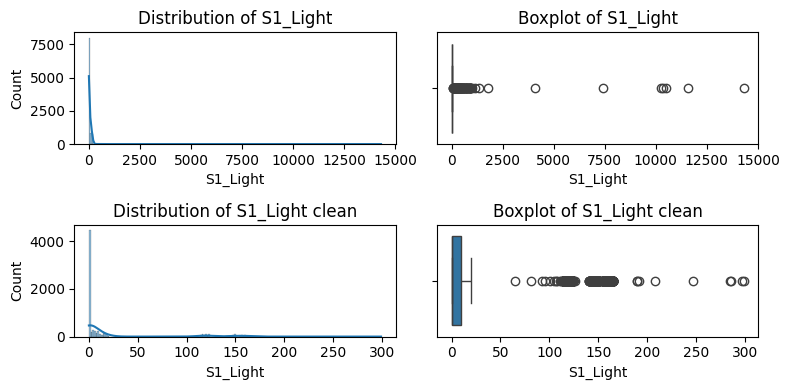

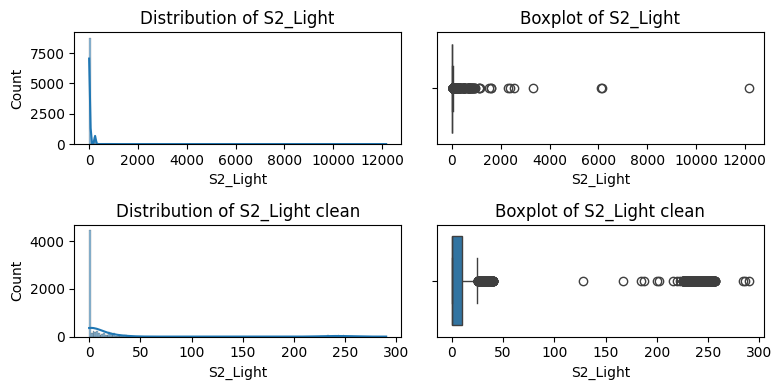

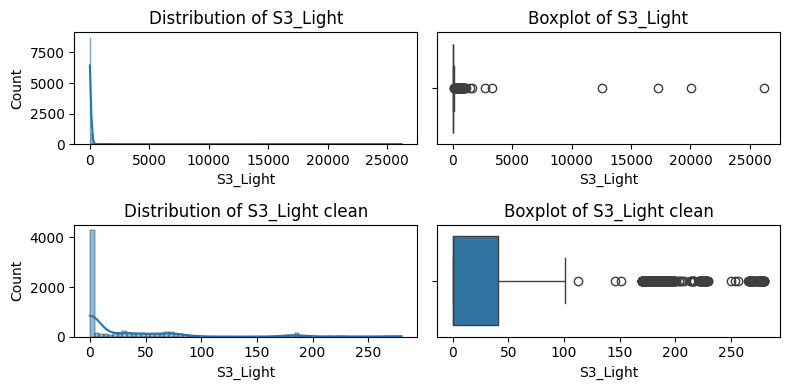

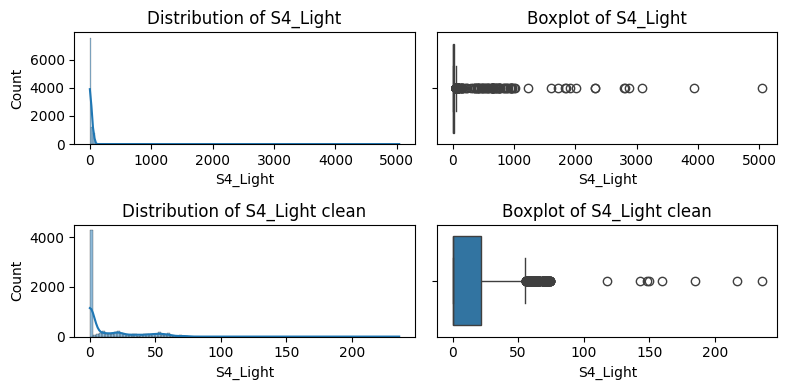

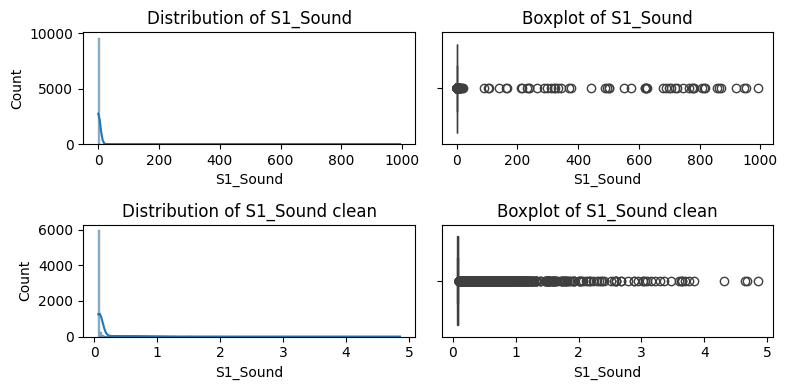

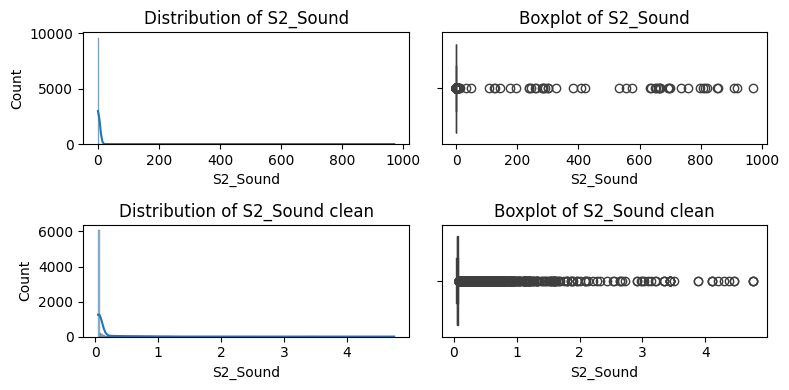

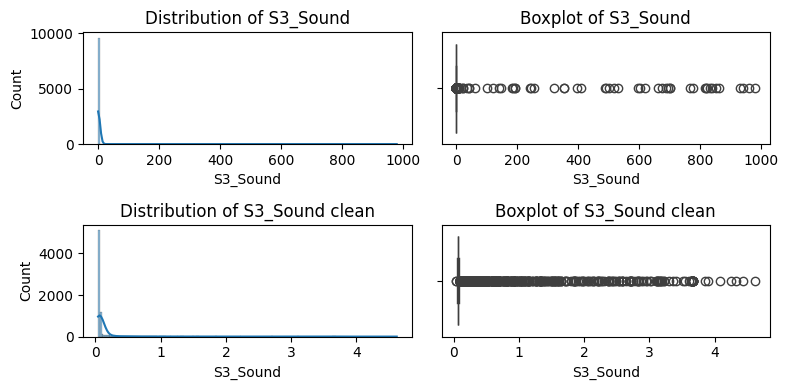

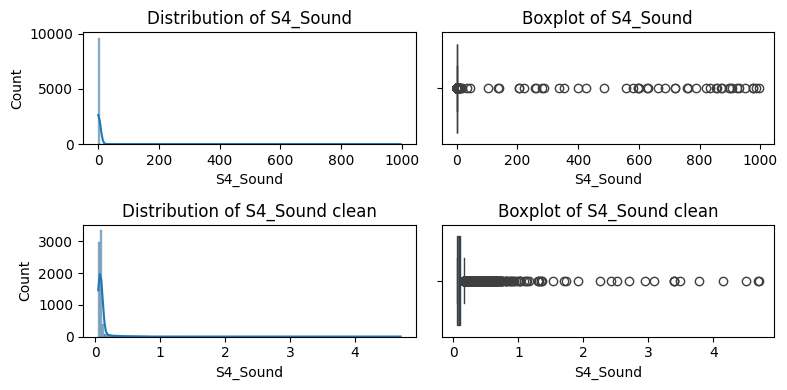

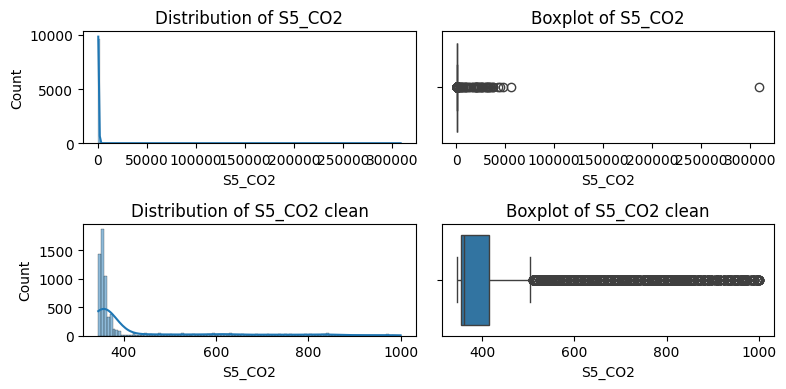

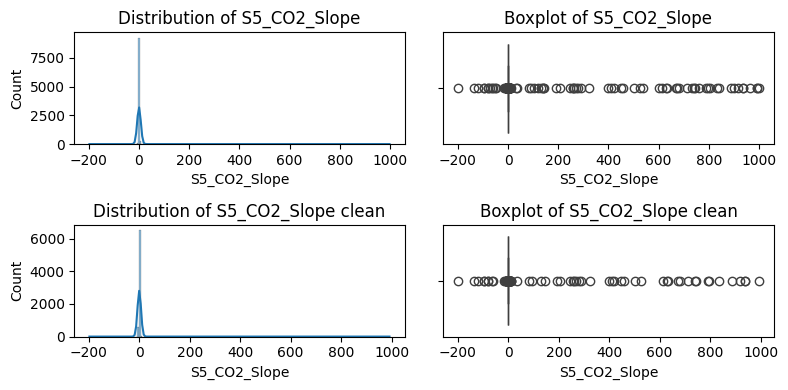

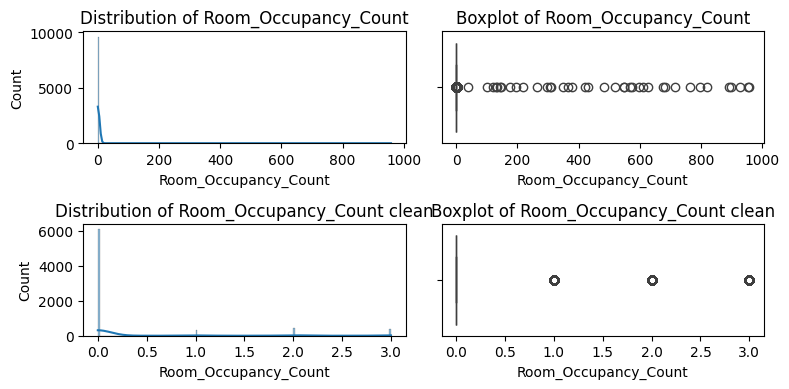

In [102]:
# Distribution + boxplot for every numerical predictor
for column in numeric_cols:
    fig, axes = plt.subplots(2, 2, figsize=(8, 4))

    sns.histplot(
        data=modDF_delR,
        x=column,
        kde=True,
        ax=axes[0,0]
    )
    axes[0,0].set_title(f"Distribution of {column}")

    sns.boxplot(
        data=modDF_delR,
        x=column,
        ax=axes[0,1]
    )
    axes[0,1].set_title(f"Boxplot of {column}")

    sns.histplot(
            data=modDf_NumC,
            x=column,
            kde=True,
            ax=axes[1,0]
        )
    axes[1,0].set_title(f"Distribution of {column} clean")

    sns.boxplot(
        data=modDf_NumC,
        x=column,
        ax=axes[1,1]
    )
    axes[1,1].set_title(f"Boxplot of {column} clean")

    plt.tight_layout()
    plt.show()

### Variables binarias

In [79]:
boolean_cols = [
    "S6_PIR",
    "S7_PIR"
]

def booleanErrors(df: pd.DataFrame, colList: list):

    errors = []

    for col in colList:
        converted = pd.to_numeric(df[col], errors="coerce")

        # Invalid if:
        # 1. Value exists but can't be converted to numeric
        # 2. Converted value is something other than 0 or 1
        invalid = (
            df[col].notna() &
            (converted.isna() |
            ~converted.isin([0, 1])))

        for idx in df.index[invalid]:
            errors.append({
                "row": idx,
                "column": col,
                "value": df.loc[idx, col]
            })

    e_df = pd.DataFrame(errors)

    if e_df.empty:
        return [e_df, []]

    same_id_rows = e_df[e_df.duplicated(subset=["row"], keep=False)]

    return [e_df, list(set(same_id_rows["row"].to_list()))]

boolErrorDF, boolSameRows = booleanErrors(modDf,boolean_cols)

print(f'Columnas analizadas: {len(boolean_cols)}')
print(f'Filas con valores erroneos: {boolErrorDF.shape[0]}')
print(f'Filas con mas de un valor erroneo: {len(boolSameRows)}')
boolErrorDF.nunique()

Columnas analizadas: 2
Filas con valores erroneos: 179
Filas con mas de un valor erroneo: 1


row       178
column      2
value     104
dtype: int64

In [80]:
boolErrorDF

,row,column,value
0,50,S6_PIR,915.0
1,99,S6_PIR,643.0
2,125,S6_PIR,71.0
3,173,S6_PIR,195.0
4,216,S6_PIR,386.0
...,...,...,...
174,9674,S7_PIR,?
175,9683,S7_PIR,invalid
176,9848,S7_PIR,894.0
177,10070,S7_PIR,invalid


### Variables de fecha y tiempo

In [81]:
def dateTimeErrors(df: pd.DataFrame, dateCol: str, timeCol: str):

    errors = []

    # Check dates

    converted = pd.to_datetime(
        df[dateCol],
        errors="coerce",
        format="%Y/%m/%d"
    )

    invalid = df[dateCol].notna() & converted.isna()

    for idx in df.index[invalid]:
        errors.append({
            "row": idx,
            "column": dateCol,
            "value": df.loc[idx, dateCol]
        })

    # Check times
    converted = pd.to_datetime(
        df[timeCol],
        errors="coerce",
        format="%H:%M:%S"
    )

    invalid = df[timeCol].notna() & converted.isna()

    for idx in df.index[invalid]:
        errors.append({
            "row": idx,
            "column": timeCol,
            "value": df.loc[idx, timeCol]
        })

    e_df = pd.DataFrame(errors)

    if e_df.empty:
        return [e_df, []]

    same_id_rows = e_df[
        e_df.duplicated(subset=["row"], keep=False)
    ]

    return [e_df, list(set(same_id_rows["row"].to_list()))]

dateTimeErrorDF, dateTimeErrorDFSameRows = dateTimeErrors(modDf,'Date','Time')

print(f'Filas con valores erroneos: {dateTimeErrorDF.shape[0]}')
print(f'Filas con mas de un valor erroneo: {len(dateTimeErrorDFSameRows)}')
dateTimeErrorDF.nunique()

Filas con valores erroneos: 1031
Filas con mas de un valor erroneo: 26


row       1005
column       2
value      535
dtype: int64

In [82]:
dateTimeErrorDF

,row,column,value
0,17,Date,2017/12/22
1,22,Date,2017/12/22
2,26,Date,2017/12/22
3,27,Date,2017/12/22
4,37,Date,2017/12/22
...,...,...,...
1026,10163,Time,06:39:42
1027,10181,Time,15:53:19
1028,10182,Time,18:26:42
1029,10271,Time,06:32:14


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------

In [83]:
print(f"Rows: {modDf.shape[0]:,}")
print(f"Columns: {modDf.shape[1]}")

# Compact data-quality summary
data_quality = pd.DataFrame({
    "dtype": modDf.dtypes,
    "missing": modDf.isna().sum(),
    "missing_pct": modDf.isna().mean() * 100,
    "n_unique": modDf.nunique()
})

data_quality.sort_values("missing_pct", ascending=False)

Rows: 10,331
Columns: 19


,dtype,missing,missing_pct,n_unique
Room_Occupancy_Count,object,132,1.277708,56
S3_Light,object,131,1.268028,338
S2_Temp,object,128,1.238989,228
S3_Temp,object,124,1.200271,169
S2_Light,object,122,1.180912,218
S5_CO2,object,121,1.171232,381
S4_Light,object,118,1.142193,227
S7_PIR,object,116,1.122834,54
S2_Sound,object,115,1.113155,322
S1_Temp,object,115,1.113155,160


Para comenzar el análisis se le asignará un tipo de dato adecuado, para ello se verificará el tipo de error que volvio los campos a tipo objeto.

In [84]:
numType = [np.number for i in range(14)] # Desde S1_Temp hasta S5_CO2_Slope pueden ser considerados numeros aun no se identifica si son tipo float o int
dtL = [np.datetime64,np.timedelta64, *numType, bool, bool, object] # Los sensores PIR son detection de persona(s) por lo que es del tipo binario 

numeric_cols = [
    "S1_Temp", "S2_Temp", "S3_Temp", "S4_Temp",
    "S1_Light", "S2_Light", "S3_Light", "S4_Light",
    "S1_Sound", "S2_Sound", "S3_Sound", "S4_Sound",
    "S5_CO2", "S5_CO2_Slope",
    "Room_Occupancy_Count"
]

boolean_cols = [
    "S6_PIR",
    "S7_PIR"
]

def is_numeric(value):
    if pd.isna(value):
        return False
    
    try:
        float(value)
        return True
    except (ValueError, TypeError):
        return False


def is_boolean(value):
    if pd.isna(value):
        return False
    
    return str(value).strip().lower() in [
        "0", "1",
        "true", "false"
    ]


def is_date(value):
    if pd.isna(value):
        return False
    
    try:
        pd.to_datetime(value, format="%Y/%m/%d")
        return True
    except (ValueError, TypeError):
        return False


def is_time(value):
    if pd.isna(value):
        return False
    
    try:
        pd.to_timedelta(str(value))
        return True
    except (ValueError, TypeError):
        return False

invalid = pd.DataFrame(
    False,
    index=modDf.index,
    columns=modDf.columns
)

invalid["Date"] = ~modDf["Date"].apply(is_date)
# invalid["Time"] = modDf["Time"].apply(is_time)

# for col in numeric_cols:
#     invalid[col] = modDf[col].apply(is_numeric)

# for col in boolean_cols:
#     invalid[col] = modDf[col].apply(is_boolean)

bad_rows = modDf[invalid.any(axis=1)]
good_rows = modDf[~invalid.any(axis=1)]

print("Valid rows:", len(good_rows))
print("Invalid rows:", len(bad_rows))

Valid rows: 9742
Invalid rows: 589


In [85]:
bad_rows

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
17,2017/12/22,10:58:22,25.06,24.81,NaN,25.56,122.0,35.0,57.0,44.0,0.25,0.07,0.07,0.05,395.0,-0.653846153846,1.0,0.0,1.0
22,2017/12/22,11:00:55,25.13,24.88,24.63,25.56,123.0,35.0,58.0,45.0,0.11,0.05,0.06,0.06,395.0,0.0615384615385,0.0,0.0,1.0
26,2017/12/22,11:02:58,25.13,24.88,24.69,25.5,123.0,35.0,59.0,44.0,0.21,0.19,0.17,0.07,405.0,0.480769230769,1.0,0.0,1.0
27,2017/12/22,11:03:28,25.13,24.88,24.69,1533.6,123.0,35.0,58.0,44.0,0.44,0.13,0.17,0.09,410.0,0.607692307692,1.0,0.0,1.0
37,2017/12/22,11:08:35,25.19,24.94,24.69,25.56,123.0,35.0,58.0,44.0,0.07,0.05,0.05,0.06,415.0,0.961538461538,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10209,2017/12/25,22:39:57,25.38,25.38,25.06,25.88,0.0,0.0,0.0,0.0,0.08,0.05,0.07,0.1,355.0,0.0,0.0,0.0,0.0
10217,2017/12/26,03:28:26,25.31,25.31,24.81,25.69,0.0,0.0,0.0,0.0,0.07,0.05,0.06,0.1,355.0,0.0,0.0,0.0,0.0
10287,2017/12/26,04:42:58,25.25,25.25,24.75,25.63,0.0,0.0,0.0,0.0,0.08,0.04,0.07,0.11,355.0,0.0,0.0,0.0,0.0
10300,NaN,01:01:41,25.38,25.44,24.94,25.69,0.0,0.0,0.0,0.0,0.07,0.05,0.06,0.06,370.0,0.0269230769231,0.0,0.0,0.0
